In [1]:
import numpy                   as     np
import pandas                  as     pd
import matplotlib.pyplot       as     plt
from   sklearn.metrics         import mean_absolute_error, mean_squared_error
from   sklearn.neighbors       import KNeighborsRegressor
from   sklearn.metrics         import mean_absolute_error
from   sklearn.pipeline        import Pipeline
from   sklearn.preprocessing   import MinMaxScaler
from   sklearn.neighbors       import KNeighborsRegressor
from   sklearn.model_selection import cross_val_score
from   sklearn.linear_model    import LinearRegression, Ridge
from   sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor
import joblib
from   datetime                import datetime

In [2]:
listings          = pd.read_csv('paris_airbnb.csv')
listings['price'] = listings['price'].str.replace('[$,]', '', regex=True).astype(float)
listings          = listings.dropna(subset=['price', 'accommodates'])

## Diviser en deux pour éviter le biais de surapprentissage

In [3]:
# 80% train / 20% test
train_df = listings.sample(frac=0.8, random_state=42)
test_df  = listings.drop(train_df.index)

print(f"Il y a {len(train_df)} logements dans le jeu d'entraînement \net {len(test_df)} logements dans le jeu de test.")

Il y a 6400 logements dans le jeu d'entraînement 
et 1600 logements dans le jeu de test.


## Calculer les métriques d'erreur (MAE, MSE, RMSE)

In [4]:
def predict_price(new_listing, train):
    temp             = train.copy()
    temp['distance'] = (temp['accommodates'] - new_listing).abs()
    temp             = temp.sort_values('distance')
    return temp.iloc[:5]['price'].mean()

# Prédictions sur le test set
test_df              = test_df.copy()
test_df['predicted'] = test_df['accommodates'].apply(
    lambda x: predict_price(x, train_df)
)

mae  = mean_absolute_error(test_df['price'], test_df['predicted'])
rmse = np.sqrt(mean_squared_error(test_df['price'], test_df['predicted']))

print(f"La MAE est de {mae:.2f} $.")    # Erreur absolue moyenne
print(f"La RMSE est de {rmse:.2f} $.")  # Racine de l'erreur quadratique moyenne

La MAE est de 62.71 $.
La RMSE est de 100.80 $.


L'erreur est de 62,71 dollar, c'est trop.

## Homogénéiser les échelles avant le calcul de distance euclidienne 
➜ Normalisation Min-Max (multivariée)

In [5]:
features = ['accommodates', 'bedrooms', 'bathrooms', 'beds']

listings_clean = listings[features + ['price']].dropna()

# Normalisation Min-Max : x_norm = (x - min) / (max - min)
listings_norm = listings_clean.copy()
for col in features:
    col_min            = listings_clean[col].min()
    col_max            = listings_clean[col].max()
    listings_norm[col] = (listings_clean[col] - col_min) / (col_max - col_min)

train_norm = listings_norm.sample(frac=0.8, random_state=42)
test_norm  = listings_norm.drop(train_norm.index)

## Généraliser le modèle KNN univarié à plusieurs features normalisées, puis, optimiser l'hyperparamètre `k` par une validation croisée.

In [6]:
X_train = train_norm[features].values
y_train = train_norm['price'].values
X_test  = test_norm[features].values
y_test  = test_norm['price'].values

# Test de k=1 à k=25
k_values, mae_values = [], []

for k in range(1, 26):
    model = KNeighborsRegressor(n_neighbors=k, metric='euclidean')
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae_values.append(mean_absolute_error(y_test, preds))
    k_values.append(k)

best_k = k_values[mae_values.index(min(mae_values))]
print(f"Le meilleur k est {best_k}. | La MAE est de {min(mae_values):.2f} $.")

Le meilleur k est 13. | La MAE est de 44.02 $.


C'est nettement mieux.

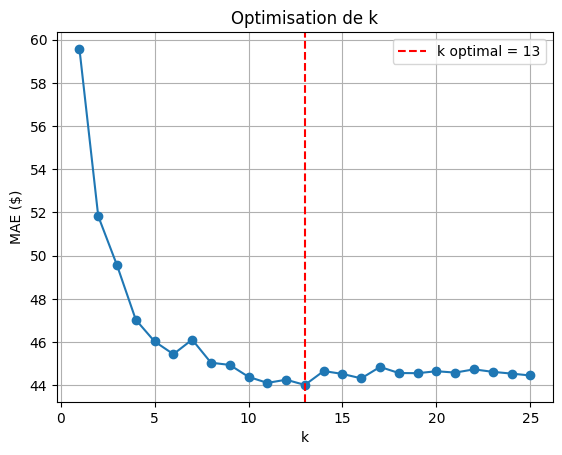

In [7]:
# Tracer une courbe du coude (Elbow)
plt.plot(k_values, mae_values, marker='o')
plt.axvline(best_k, color='red', linestyle='--', label=f'k optimal = {best_k}')
plt.xlabel('k'); plt.ylabel('MAE ($)'); plt.title('Optimisation de k')
plt.legend(); plt.grid(True)

## Faire le pipeline sklearn complet pour enchaîner normalisation et le modèle

In [8]:
X = listings_clean[features].values
y = listings_clean['price'].values

pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn',    KNeighborsRegressor(n_neighbors=best_k, metric='euclidean'))
])

# Validation croisée 5-fold
scores = cross_val_score(pipeline, X, y,
                         cv=5,
                         scoring='neg_mean_absolute_error')

print(f"La MAE moyenne (CV-5) est de {-scores.mean():.2f} $ à ± {scores.std():.2f} $.")

La MAE moyenne (CV-5) est de 46.85 $ à ± 5.34 $.


Aprés avoir était tester 5 fois, le modèle de trompe de  46,85$ avec plus ou moins 5,34$ .

## Calculer l'amélioration du modèle

In [9]:
# mae et best_k sont déjà calculés dans les cellules précédentes
mae_depart = mean_absolute_error(test_df['price'], test_df['predicted'])  # 62.71 $
mae_k_optimal = min(mae_values)                                           # 44.02 $
mae_cv_finale = -scores.mean()                                            # 46.85 $

amelioration_k = (mae_depart - mae_k_optimal) / mae_depart * 100
amelioration_cv = (mae_depart - mae_cv_finale) / mae_depart * 100

print(f"La MAE de départ est de                   {mae_depart:.2f} $")
print(f"La MAE du paramètre k optimal est de      {mae_k_optimal:.2f} $ → l'amélioration est de {amelioration_k:.9f} %, arrondi à {amelioration_k:.2f}")
print(f"La MAE CV* (erreur moyenne) finale est de {mae_cv_finale:.2f} $ → l'amélioration est de {amelioration_cv:.9f} %, arrondi à {amelioration_cv:.2f}")

La MAE de départ est de                   62.71 $
La MAE du paramètre k optimal est de      44.02 $ → l'amélioration est de 29.799785810 %, arrondi à 29.80
La MAE CV* (erreur moyenne) finale est de 46.85 $ → l'amélioration est de 25.283511753 %, arrondi à 25.28


*CV signifie validation croisée. Il y a en eu 5.

In [10]:
# Les features et la cible
features = ['accommodates', 'bedrooms', 'bathrooms', 'beds']
X = listings_clean[features].values
y = listings_clean['price'].values

# Dictionnaire des algorithmes à tester
algorithmes = {
    "KNN (le modèle)"     : KNeighborsRegressor(n_neighbors=13, metric='euclidean'),
    "Régression linéaire" : LinearRegression(),
    "Ridge"               : Ridge(alpha=1.0),
    "Random Forest"       : RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting"   : GradientBoostingRegressor(n_estimators=100, random_state=42),
}

# Benchmark avec validation croisée CV-5
resultats = []

for nom, modele in algorithmes.items():
    pipeline = Pipeline([
        ('scaler', MinMaxScaler()),
        ('model',  modele)
    ])
    scores = cross_val_score(pipeline, X, y,
                             cv=5,
                             scoring='neg_mean_absolute_error')
    mae_moyenne = -scores.mean()
    mae_std     = scores.std()
    resultats.append({
        "Algorithme" : nom,
        "MAE moyenne": round(mae_moyenne, 2),
        "± (std)"    : round(mae_std, 2)
    })

# Affichage trié du meilleur au moins bon
df_resultats = pd.DataFrame(resultats)
df_resultats = df_resultats.sort_values("MAE moyenne")
print(df_resultats.to_string(index=False))

         Algorithme  MAE moyenne  ± (std)
  Gradient Boosting        41.84     1.04
      Random Forest        42.94     1.63
Régression linéaire        43.25     1.68
              Ridge        43.27     1.63
    KNN (le modèle)        46.85     5.34


Le meilleur est "Gradient Boosting". Nonobstant pour éviter le surapprentissage, je préfère "Reandom Forest".

## Le modèle Random Forest

In [11]:
# Les features du KNN
features = ['accommodates', 'bedrooms', 'bathrooms', 'beds']
listings_clean = listings[features + ['price']].dropna()

X = listings_clean[features].values
y = listings_clean['price'].values

# Séparer
train_rf = listings_clean.sample(frac=0.8, random_state=42)
test_rf   = listings_clean.drop(train_rf.index)

X_train = train_rf[features].values
y_train = train_rf['price'].values
X_test  = test_rf[features].values
y_test  = test_rf['price'].values

# Entraîner
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# On évalue
preds = rf.predict(X_test)
mae   = mean_absolute_error(y_test, preds)
print(f"MAE Random Forest : {mae:.2f} $")

MAE Random Forest : 44.95 $


### Optimiser le nombre d'arbre

In [12]:
n_values, mae_values = [], []

for n in range(10, 201, 10):  # On teste de 10 à 200 arbres par pas de 10
    rf = RandomForestRegressor(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    preds = rf.predict(X_test)
    mae_values.append(mean_absolute_error(y_test, preds))
    n_values.append(n)

best_n = n_values[mae_values.index(min(mae_values))]
print(f"Le meilleur n_estimators est {best_n} | La MAE est {min(mae_values):.2f} $")

Le meilleur n_estimators est 200 | La MAE est 44.77 $


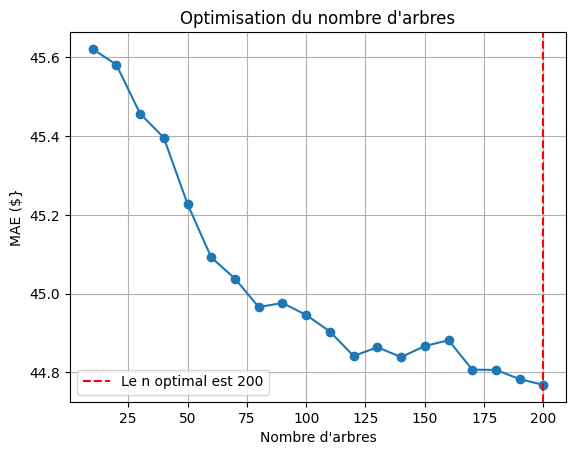

In [13]:
# Tracer la courbe du nombre d'arbres vs MAE
plt.plot(n_values, mae_values, marker='o')
plt.axvline(best_n, color='red', linestyle='--', label=f'Le n optimal est {best_n}')
plt.xlabel('Nombre d\'arbres'); plt.ylabel('MAE ($}')
plt.title('Optimisation du nombre d\'arbres')
plt.legend(); plt.grid(True)

### Faire le pipeline complet avec la validation croisée

In [14]:
pipeline_rf = Pipeline([
    ('scaler', MinMaxScaler()),
    ('model',  RandomForestRegressor(n_estimators=best_n, random_state=42))
])

scores = cross_val_score(pipeline_rf, X, y,
                         cv=5,
                         scoring='neg_mean_absolute_error')

mae_rf  = -scores.mean()
std_rf  =  scores.std()
print(f"La MAE de Random Forest (CV-5) est {mae_rf:.2f} $ à ± {std_rf:.2f} $")

La MAE de Random Forest (CV-5) est 42.97 $ à ± 1.70 $


C'est très bon.

#### Quelle variable compte le plus ?

In [15]:
rf_final = RandomForestRegressor(n_estimators=best_n, random_state=42)
rf_final.fit(X_train, y_train)

# Affichage de l'importance de chaque feature
importances = rf_final.feature_importances_
for feature, score in sorted(zip(features, importances), key=lambda x: -x[1]):
    print(f"▫️ {feature:<15} ➜ {score:.3f}, soit ({score*100:.1f} %)")

▫️ bathrooms       ➜ 0.525, soit (52.5 %)
▫️ accommodates    ➜ 0.193, soit (19.3 %)
▫️ bedrooms        ➜ 0.154, soit (15.4 %)
▫️ beds            ➜ 0.129, soit (12.9 %)


* La salle de bain est la pièce la plus importante (+52 %).  
* Moins de 20 % d'imfluence pour le nombre de personnes qu'accueil le logement.  
* Finalement moins de 15 % pour les chambres et les lits.

### Sauvegarder le modèle Scikit-learn avec les méta données

In [16]:
joblib.dump(pipeline_rf, 'random_forest_airbnb.pkl')

# Sauvegarder les infos du modèle dans un fichier texte
meta = {
    "modele"       : "RandomForestRegressor",
    "n_estimators" : best_n,
    "features"     : features,
    "mae_cv5"      : round(mae_rf, 2),
    "std_cv5"      : round(std_rf, 2),
    "date"         : datetime.now().strftime("%Y-%m-%d %H:%M"),
}

joblib.dump(meta, 'random_forest_airbnb_meta.pkl')
print("Le modèle et les métadonnées sont sauvegardés ✅")

# Recharger et afficher les infos
meta_charge = joblib.load('random_forest_airbnb_meta.pkl')
for cle, valeur in meta_charge.items():
    print(f"{cle:<15} : {valeur}")

Le modèle et les métadonnées sont sauvegardés ✅
modele          : RandomForestRegressor
n_estimators    : 200
features        : ['accommodates', 'bedrooms', 'bathrooms', 'beds']
mae_cv5         : 42.97
std_cv5         : 1.7
date            : 2026-03-30 20:32
